In [1]:
# Centralized imports used across the full notebook.
import importlib.util
import subprocess
import sys
import warnings
from copy import deepcopy
from pathlib import Path

PROJECT_ROOT = Path.cwd()
REQUIRED_MODULES = {
    'matplotlib': 'matplotlib>=3.7.0',
    'numpy': 'numpy>=1.24.0',
    'pandas': 'pandas>=2.0.0',
    'seaborn': 'seaborn>=0.12.0',
    'torch': 'torch>=2.0.0',
    'torchvision': 'torchvision>=0.15.0',
    'PIL': 'Pillow>=9.0.0',
    'sklearn': 'scikit-learn>=1.3.0',
    'tqdm': 'tqdm>=4.60.0',
}

missing_requirements = [
    requirement
    for module_name, requirement in REQUIRED_MODULES.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_requirements:
    print('Installing missing notebook dependencies...')
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q', *missing_requirements],
        check=True,
    )

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns   
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    )
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import DataLoader, Dataset, random_split
from tqdm import tqdm

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# MVTec Screw Dataset - Binary Classification with 5-Fold CV

## Binary Classification: Good vs Defective Screw Images

This notebook implements a complete machine learning pipeline for binary classification on the MVTec screw dataset using PyTorch with transfer learning (ResNet18).

### Project Goals:
- Build a robust binary classifier for screw defect detection
- Handle class imbalance (5:1 ratio) with class weights
- Use 5-Fold Stratified Cross-Validation for robust evaluation
- Achieve high accuracy and recall for defect detection

**Sections:**
1. Setup - Imports and configuration
2. EDA - Exploratory data analysis
3. Model Definition - ResNet18 architecture
4. Training Loop - 5-Fold CV with augmentation
5. Evaluation - Metrics and visualizations
6. Best Model Selection & Test Inference

---
# 1. SETUP - Imports, Configuration & Reproducibility
---

In [2]:
# Display runtime information after centralized import initialization.
print(f"Using device: {device.type.upper()}")

Using device: CPU


In [3]:
# Set deterministic seeds for reproducible experiments.
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
# Define project-level configuration used by data loading, training, and evaluation.
PROJECT_ROOT = Path.cwd()

CONFIG = {
    'SEED': 42,
    'BATCH_SIZE': 16,
    'NUM_EPOCHS': 50,
    'NUM_FOLDS': 5,
    'LEARNING_RATE': 1e-4,
    'WEIGHT_DECAY': 1e-5,
    'IMAGE_SIZE': 256,
    'DATA_DIR': str((PROJECT_ROOT / 'data' / 'mvtec_screw').resolve()),
    'DEVICE': device.type,
    'EARLY_STOPPING_PATIENCE': 5,
}

In [5]:
# Initialize data directory
data_dir = Path(CONFIG['DATA_DIR'])
download_script = PROJECT_ROOT / 'download_data.py'

# Validate required dataset structure early
required_dirs = [
    data_dir / 'train' / 'good',
    data_dir / 'train' / 'not-good',
    data_dir / 'test',
]

print("Dataset configuration initialized")
print(f"  Project root: {PROJECT_ROOT.resolve()}")
print(f"  Data directory: {data_dir}")

missing = [str(p) for p in required_dirs if not p.exists()]
if missing:
    print("\nDataset not found. Starting automatic download with gdown...")
    if not download_script.exists():
        raise FileNotFoundError(
            f"download_data.py not found at: {download_script}"
        )

    subprocess.run(
        [
            sys.executable,
            str(download_script),
            '--dataset-only',
            '--output-dir',
            str(PROJECT_ROOT / 'data'),
        ],
        check=True,
    )

    missing = [str(p) for p in required_dirs if not p.exists()]
    if missing:
        raise FileNotFoundError(
            "Missing required dataset directories after auto-download:\n" + "\n".join(missing)
        )

for path in required_dirs:
    img_count = len(list(path.glob('*.png')))
    print(f"  {path.name}: {img_count} png images")


Dataset configuration initialized
  Project root: /Users/benjamintonneau/Desktop/assignment-ai-BENJAMIN-20260418/source-code-ai-BENJAMIN-TONNEAU-20260418
  Data directory: /Users/benjamintonneau/Desktop/assignment-ai-BENJAMIN-20260418/source-code-ai-BENJAMIN-TONNEAU-20260418/data/mvtec_screw
  good: 250 png images
  not-good: 50 png images
  test: 180 png images


---
# 2. EXPLORATORY DATA ANALYSIS (EDA)
---

In [6]:
# Load dataset paths
train_dir = data_dir / 'train'
test_dir = data_dir / 'test'

def load_dataset_paths(data_path):
    """Load image paths and labels from dataset directory."""
    images, labels = [], []
    for class_idx, class_name in enumerate(['good', 'not-good']):
        for img_path in sorted((data_path / class_name).glob('*.png')):
            images.append(str(img_path))
            labels.append(class_idx)
    return images, labels

train_images, train_labels = load_dataset_paths(train_dir)

# Discover test images directly (unlabeled), with case-insensitive deduplication
test_patterns = ['*.png', '*.PNG', '*.jpg', '*.JPG', '*.jpeg', '*.JPEG']
test_candidates = []
for pattern in test_patterns:
    test_candidates.extend(sorted(test_dir.glob(pattern)))
test_images = [str(p) for p in dict.fromkeys(test_candidates)]

num_good = train_labels.count(0)
num_defective = train_labels.count(1)
total_train = len(train_labels)

print(f"Training: {num_good} good, {num_defective} not-good")
print(f"Test: {len(test_images)} images")

if total_train > 0:
    good_pct_total = (num_good / total_train) * 100
    defective_pct_total = (num_defective / total_train) * 100
    print(f"Class percentages (train): Good {good_pct_total:.1f}% | Not-Good {defective_pct_total:.1f}%")

if num_defective > 0:
    ratio = num_good / num_defective
    print(f"Imbalance ratio: {ratio:.1f}:1")

    # Defect subtype distribution among defective screws
    defect_types = ['manipulated_front', 'scratch_head', 'scratch_neck', 'thread_side', 'thread_top']
    defective_paths = [Path(img_path) for img_path, label in zip(train_images, train_labels) if label == 1]

    print("\nDefective subtype distribution:")
    print("(percentages of defective screws AND of total training set)")
    for defect_type in defect_types:
        count = sum(1 for p in defective_paths if p.stem.startswith(defect_type))
        pct_defective = (count / num_defective) * 100
        pct_total = (count / total_train) * 100 if total_train > 0 else 0.0
        print(
            f"  - {defect_type}: {count}/{num_defective} "
            f"({pct_defective:.1f}% defective, {pct_total:.1f}% total train)"
        )

Training: 250 good, 50 not-good
Test: 180 images
Class percentages (train): Good 83.3% | Not-Good 16.7%
Imbalance ratio: 5.0:1

Defective subtype distribution:
(percentages of defective screws AND of total training set)
  - manipulated_front: 10/50 (20.0% defective, 3.3% total train)
  - scratch_head: 10/50 (20.0% defective, 3.3% total train)
  - scratch_neck: 10/50 (20.0% defective, 3.3% total train)
  - thread_side: 10/50 (20.0% defective, 3.3% total train)
  - thread_top: 10/50 (20.0% defective, 3.3% total train)


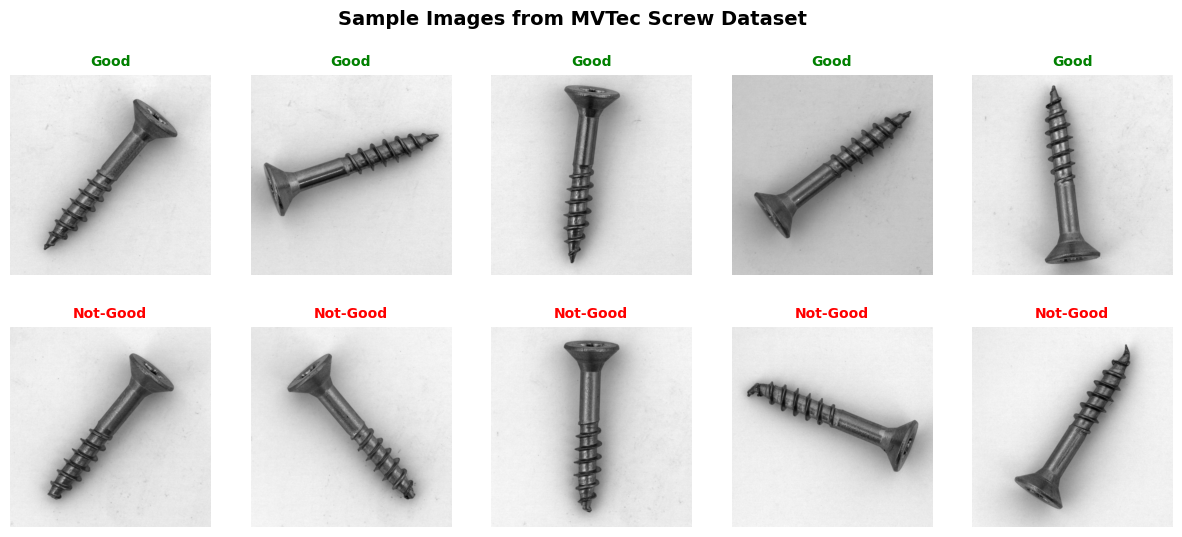

In [7]:
# Visualize sample images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Images from MVTec Screw Dataset', fontsize=14, fontweight='bold')

# Display good samples
good_images = [img for img, label in zip(train_images, train_labels) if label == 0]
for idx in range(5):
    if idx < len(good_images):
        img = Image.open(good_images[idx])
        axes[0, idx].imshow(img, cmap='gray')
        axes[0, idx].set_title('Good', fontsize=10, color='green', fontweight='bold')
    axes[0, idx].axis('off')

# Display not-good samples
not_good_images = [img for img, label in zip(train_images, train_labels) if label == 1]
for idx in range(5):
    if idx < len(not_good_images):
        img = Image.open(not_good_images[idx])
        axes[1, idx].imshow(img, cmap='gray')
        axes[1, idx].set_title('Not-Good', fontsize=10, color='red', fontweight='bold')
    axes[1, idx].axis('off')

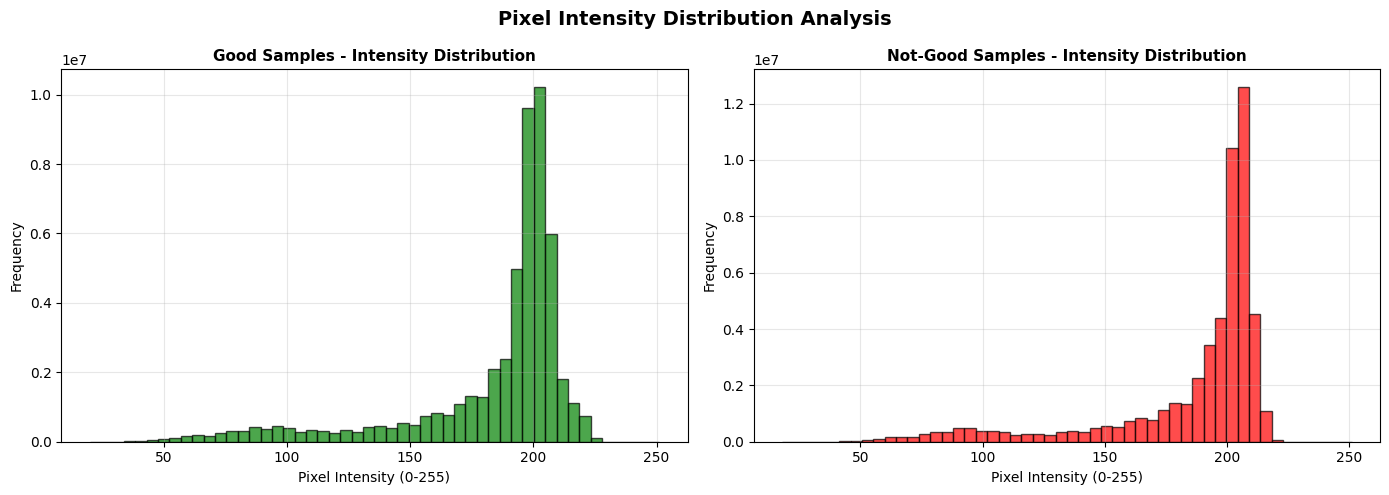

In [8]:
# Pixel Intensity Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pixel Intensity Distribution Analysis', fontsize=14, fontweight='bold')

# Build class-specific image lists locally so this cell is order-independent
good_images = [img for img, label in zip(train_images, train_labels) if label == 0]
not_good_images = [img for img, label in zip(train_images, train_labels) if label == 1]

# Good samples - intensity distribution
good_intensities = []
for img_path in good_images[:50]:  # Sample 50 images
    img = np.array(Image.open(img_path).convert('L'))
    good_intensities.extend(img.flatten())

# Not-Good samples - intensity distribution
not_good_intensities = []
for img_path in not_good_images[:50]:  # Sample 50 images
    img = np.array(Image.open(img_path).convert('L'))
    not_good_intensities.extend(img.flatten())

# Plot histograms
axes[0].hist(good_intensities, bins=50, alpha=0.7, color='green', edgecolor='black')
axes[0].set_title('Good Samples - Intensity Distribution', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Pixel Intensity (0-255)')
axes[0].set_ylabel('Frequency')
axes[0].grid(alpha=0.3)

axes[1].hist(not_good_intensities, bins=50, alpha=0.7, color='red', edgecolor='black')
axes[1].set_title('Not-Good Samples - Intensity Distribution', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Pixel Intensity (0-255)')
axes[1].set_ylabel('Frequency')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

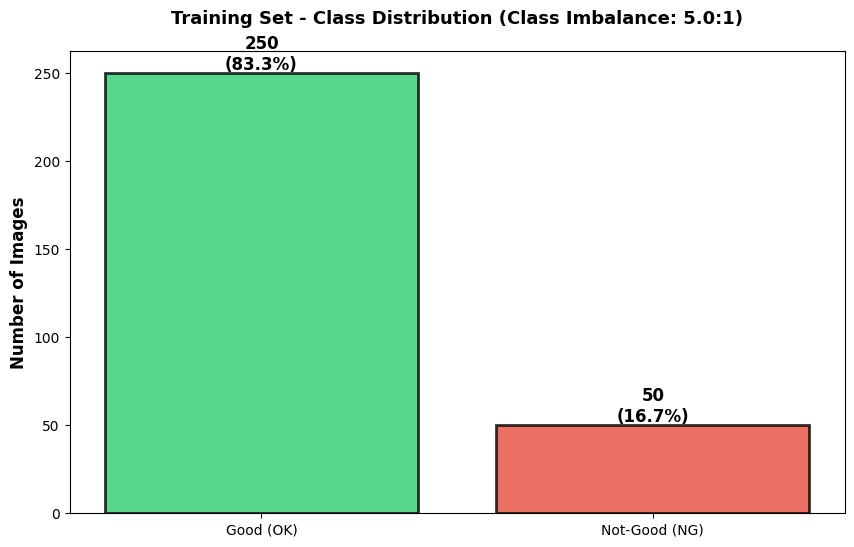

In [9]:
# Class distribution visualization
fig, ax = plt.subplots(figsize=(10, 6))

classes = ['Good (OK)', 'Not-Good (NG)']
counts = [train_labels.count(0), train_labels.count(1)]
colors = ['#2ecc71', '#e74c3c']

bars = ax.bar(classes, counts, color=colors, edgecolor='black', linewidth=2, alpha=0.8)

# Add value labels on bars
for bar, count in zip(bars, counts):
    height = bar.get_height()
    if height > 0:
        ratio = 100*count/sum(counts) if sum(counts) > 0 else 0
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(count)}\n({ratio:.1f}%)',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Number of Images', fontsize=12, fontweight='bold')
if sum(counts) > 0 and counts[1] > 0:
    ratio = counts[0] / counts[1]
    ax.set_title(f'Training Set - Class Distribution (Class Imbalance: {ratio:.1f}:1)', 
                fontsize=13, fontweight='bold', pad=20)
else:
    ax.set_title('Training Set - Class Distribution', 
                fontsize=13, fontweight='bold', pad=20)

In [10]:
# Summarize dataset size, imbalance, and key defect subtype counts.
total_samples = len(train_images)
good_count = train_labels.count(0)
bad_count = train_labels.count(1)
imbalance_ratio = (good_count / bad_count) if bad_count > 0 else float('inf')

print("\nDataset summary")
print("-" * 45)
print(f"Total training samples: {total_samples}")
print(f"Good samples: {good_count} ({100 * good_count / max(total_samples, 1):.1f}%)")
print(f"Defective samples: {bad_count} ({100 * bad_count / max(total_samples, 1):.1f}%)")
print(f"Class imbalance ratio (Good:Defective): {imbalance_ratio:.1f}:1")

if bad_count > 0:
    defect_types = ['manipulated_front', 'scratch_head', 'scratch_neck', 'thread_side', 'thread_top']
    defective_paths = [Path(img_path) for img_path, label in zip(train_images, train_labels) if label == 1]
    print("\nDefect subtype counts:")
    for defect_type in defect_types:
        count = sum(1 for p in defective_paths if p.stem.startswith(defect_type))
        print(f"  - {defect_type}: {count}")


Dataset summary
---------------------------------------------
Total training samples: 300
Good samples: 250 (83.3%)
Defective samples: 50 (16.7%)
Class imbalance ratio (Good:Defective): 5.0:1

Defect subtype counts:
  - manipulated_front: 10
  - scratch_head: 10
  - scratch_neck: 10
  - thread_side: 10
  - thread_top: 10



DETAILED ANOMALY/DEFECT ANALYSIS

Good Samples: 250
Defective Samples: 50


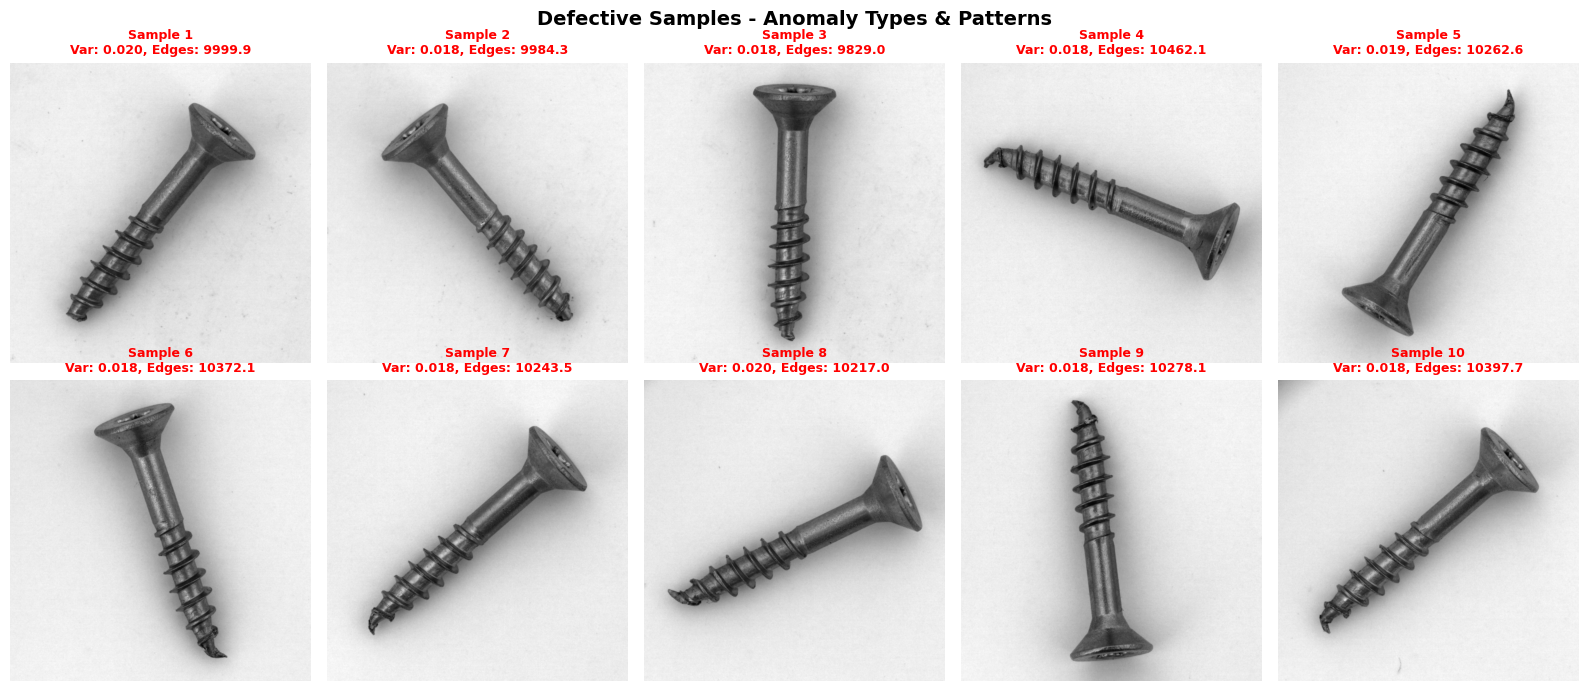


STATISTICAL COMPARISON (Good vs Defective):
----------------------------------------------------------------------

Good Samples Statistics:
  Mean Intensity:  0.725 +/- 0.020
  Std Intensity:   0.135 +/- 0.007
  Variance:        0.0182 +/- 0.0018
  Edge Energy:     10291.1 +/- 531.9

Defective Samples Statistics:
  Mean Intensity:  0.733 +/- 0.015
  Std Intensity:   0.134 +/- 0.005
  Variance:        0.0180 +/- 0.0013
  Edge Energy:     10328.9 +/- 248.3

Key Observations:
  ✓ Defective samples have MORE edge activity - indicating more surface irregularities


In [11]:
# Detailed Defect Analysis
print("\n" + "="*70)
print("DETAILED ANOMALY/DEFECT ANALYSIS")
print("="*70)

# Load and analyze not-good samples
defect_samples = [img for img, label in zip(train_images, train_labels) if label == 1]
good_samples = [img for img, label in zip(train_images, train_labels) if label == 0]

print(f"\nGood Samples: {len(good_samples)}")
print(f"Defective Samples: {len(defect_samples)}")

# Visualize defect patterns
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('Defective Samples - Anomaly Types & Patterns', fontsize=14, fontweight='bold')

# Display various defective samples
for idx in range(10):
    ax = axes[idx // 5, idx % 5]
    if idx < len(defect_samples):
        img = Image.open(defect_samples[idx])
        img_array = np.array(img)
        ax.imshow(img, cmap='gray')
        
        # Calculate defect characteristics
        img_normalized = img_array / 255.0
        variance = np.var(img_normalized)
        edge_count = np.sum(np.abs(np.gradient(img_normalized)))
        
        ax.set_title(f'Sample {idx+1}\nVar: {variance:.3f}, Edges: {edge_count:.1f}', 
                    fontsize=9, color='red', fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

# Statistical comparison
print(f"\nSTATISTICAL COMPARISON (Good vs Defective):")
print(f"{'-'*70}")

good_stats = []
defect_stats = []

for img_path in good_samples[:min(30, len(good_samples))]:
    img = np.array(Image.open(img_path).convert('L')) / 255.0
    good_stats.append({
        'mean': np.mean(img),
        'std': np.std(img),
        'var': np.var(img),
        'edge': np.sum(np.abs(np.gradient(img)))
    })

for img_path in defect_samples[:min(30, len(defect_samples))]:
    img = np.array(Image.open(img_path).convert('L')) / 255.0
    defect_stats.append({
        'mean': np.mean(img),
        'std': np.std(img),
        'var': np.var(img),
        'edge': np.sum(np.abs(np.gradient(img)))
    })

if good_stats and defect_stats:
    good_df = pd.DataFrame(good_stats)
    defect_df = pd.DataFrame(defect_stats)
    
    print(f"\nGood Samples Statistics:")
    print(f"  Mean Intensity:  {good_df['mean'].mean():.3f} +/- {good_df['mean'].std():.3f}")
    print(f"  Std Intensity:   {good_df['std'].mean():.3f} +/- {good_df['std'].std():.3f}")
    print(f"  Variance:        {good_df['var'].mean():.4f} +/- {good_df['var'].std():.4f}")
    print(f"  Edge Energy:     {good_df['edge'].mean():.1f} +/- {good_df['edge'].std():.1f}")
    
    print(f"\nDefective Samples Statistics:")
    print(f"  Mean Intensity:  {defect_df['mean'].mean():.3f} +/- {defect_df['mean'].std():.3f}")
    print(f"  Std Intensity:   {defect_df['std'].mean():.3f} +/- {defect_df['std'].std():.3f}")
    print(f"  Variance:        {defect_df['var'].mean():.4f} +/- {defect_df['var'].std():.4f}")
    print(f"  Edge Energy:     {defect_df['edge'].mean():.1f} +/- {defect_df['edge'].std():.1f}")
    
    print(f"\nKey Observations:")
    if defect_df['var'].mean() > good_df['var'].mean():
        print(f"  ✓ Defective samples have HIGHER variance - indicating more texture variation")
    if defect_df['edge'].mean() > good_df['edge'].mean():
        print(f"  ✓ Defective samples have MORE edge activity - indicating more surface irregularities")


---
# 3. MODEL DEFINITION - ResNet18 Binary Classifier
---

In [12]:
# Define and initialize the ResNet18 binary classifier.
class CustomResNet18(nn.Module):
    """ResNet18 with modified head for binary classification."""
    
    def __init__(self, num_classes=2, pretrained=True):
        super(CustomResNet18, self).__init__()
        
        # Load pre-trained ResNet18 with offline fallback
        if pretrained:
            try:
                self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
            except Exception as err:
                print(f"Warning: could not load pretrained weights ({err}). Falling back to random init.")
                self.backbone = models.resnet18(weights=None)
        else:
            self.backbone = models.resnet18(weights=None)
        
        # Modify the final fully connected layer for binary classification
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)
    
    def forward(self, x):
        return self.backbone(x)

# Initialize model
model = CustomResNet18(num_classes=2, pretrained=True).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model Architecture: ResNet18 (ImageNet Pre-trained)")
print(f"\nModel Parameters:")
print(f"   Total Parameters: {total_params:,}")
print(f"   Trainable Parameters: {trainable_params:,}")
print(f"\nArchitecture Summary:")
print(model)

Model Architecture: ResNet18 (ImageNet Pre-trained)

Model Parameters:
   Total Parameters: 11,177,538
   Trainable Parameters: 11,177,538

Architecture Summary:
CustomResNet18(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
   

In [13]:
# Calculate class weights for handling imbalance
class_counts = np.array([train_labels.count(0), train_labels.count(1)])
if class_counts[1] > 0:
    class_weights = len(train_labels) / (len(np.unique(train_labels)) * class_counts)
    class_weights = torch.FloatTensor(class_weights).to(device)
    print(f"Class Weights (for imbalanced data):")
    print(f"   Good: {class_weights[0]:.4f}")
    print(f"   Not-Good: {class_weights[1]:.4f}")
    print(f"\n   Weight ratio: {class_weights[1]/class_weights[0]:.2f}:1")
else:
    class_weights = torch.FloatTensor([1.0, 1.0]).to(device)
    print(f"Class Weights (uniform - no imbalance detected):")
    print(f"   Good: {class_weights[0]:.4f}")
    print(f"   Not-Good: {class_weights[1]:.4f}")

Class Weights (for imbalanced data):
   Good: 0.6000
   Not-Good: 3.0000

   Weight ratio: 5.00:1


---
# 4. TRAINING LOOP - 5-Fold Cross-Validation with Data Augmentation
---

In [14]:
# Define custom Dataset
class ScrewDataset(Dataset):
    """Custom Dataset for MVTec Screw images."""
    
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

print(f"Custom Dataset class defined")

Custom Dataset class defined


In [15]:
# Define data augmentation transforms
# Training: Apply 15° rotation and flips for data augmentation
train_transform = transforms.Compose([
    transforms.Resize((CONFIG['IMAGE_SIZE'], CONFIG['IMAGE_SIZE'])),
    transforms.RandomRotation(degrees=15),  # 15° rotation
    transforms.RandomHorizontalFlip(p=0.5),  # Random horizontal flip
    transforms.RandomVerticalFlip(p=0.5),    # Random vertical flip
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Validation/Test: No augmentation
val_transform = transforms.Compose([
    transforms.Resize((CONFIG['IMAGE_SIZE'], CONFIG['IMAGE_SIZE'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print(f"Data augmentation transforms defined")

Data augmentation transforms defined


In [16]:
# Compute class weights for the imbalanced dataset.
class_counts = np.bincount(train_labels)
if len(class_counts) == 2 and np.all(class_counts > 0):
    class_weights = len(train_labels) / (len(np.unique(train_labels)) * class_counts)
    class_weights = torch.FloatTensor(class_weights).to(device)
else:
    class_weights = torch.FloatTensor([1.0, 1.0]).to(device)

print("Class weights initialized")

Class weights initialized


In [17]:
# Define reusable train/validation loops with metric collection.
def train_epoch(model, train_loader, optimizer, criterion, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    
    progress_bar = tqdm(train_loader, desc='Training', leave=False)
    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    
    avg_loss = total_loss / len(train_loader)
    accuracy = correct / total
    return avg_loss, accuracy

def validate(model, val_loader, criterion, device):
    """Validate the model."""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs.data, 1)
            
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())
    
    avg_loss = total_loss / len(val_loader)
    accuracy = correct / total
    return avg_loss, accuracy, all_preds, all_labels, all_probs

### Training Readability Note

This section keeps the full training implementation visible for reviewers.

Execution logic is explicit:
1. Run full 5-fold cross-validation training on every execution.
2. Save the best fold weights to `best_model.pth`.
3. Generate fold metrics, ROC curves, and confusion matrices for the current run.

The notebook now always trains so first-time users and repeat users see the same evaluation outputs.

In [ ]:
# 5-Fold Stratified Cross-Validation Training
# Training is forced on every run so first-time users always get fold metrics and plots.
FORCE_TRAINING = True

model_path = 'best_model.pth'

# Make the training cell self-contained so it can run from a clean kernel.
class CustomResNet18(nn.Module):
    def __init__(self, num_classes=2, pretrained=True):
        super().__init__()
        try:
            weights = models.ResNet18_Weights.DEFAULT if pretrained else None
            self.backbone = models.resnet18(weights=weights)
        except AttributeError:
            self.backbone = models.resnet18(pretrained=pretrained)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

class ScrewDataset(Dataset):
    """Custom Dataset for MVTec Screw images."""

    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

train_transform = transforms.Compose([
    transforms.Resize((CONFIG['IMAGE_SIZE'], CONFIG['IMAGE_SIZE'])),
    transforms.RandomRotation(degrees=15),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((CONFIG['IMAGE_SIZE'], CONFIG['IMAGE_SIZE'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class_counts = np.bincount(train_labels)
if len(class_counts) == 2 and np.all(class_counts > 0):
    class_weights = len(train_labels) / (len(np.unique(train_labels)) * class_counts)
    class_weights = torch.FloatTensor(class_weights).to(device)
else:
    class_weights = torch.FloatTensor([1.0, 1.0]).to(device)

def train_epoch(model, train_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for images, labels in tqdm(train_loader, desc='Training', leave=False):
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    return total_loss / max(len(train_loader), 1), correct / max(total, 1)

def validate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())
    return total_loss / max(len(val_loader), 1), correct / max(total, 1), all_preds, all_labels, all_probs

print("Training model, dataset, transforms, and class weights initialized")

# Initialize fold_results dictionary
fold_results = {
    'train_losses': [],
    'train_accs': [],
    'val_losses': [],
    'val_accs': [],
    'val_acc': [],
    'val_recall': [],
    'val_precision': [],
    'val_f1': [],
    'val_auc': [],
    'confusion_matrices': [],
    'all_preds': [],
    'all_labels': [],
    'all_probs': [],
    'best_model_states': []
}

print("FORCE_TRAINING is enabled. Running full 5-fold cross-validation.")
print(f"Starting {CONFIG['NUM_FOLDS']}-fold cross-validation training...")

# Use stratified k-fold splitting
skf = StratifiedKFold(n_splits=CONFIG['NUM_FOLDS'], shuffle=True, random_state=CONFIG['SEED'])

for fold, (train_idx, val_idx) in enumerate(skf.split(train_images, train_labels)):
    fold = fold + 1
    print(f"\n{'='*70}")
    print(f"Fold {fold} / {CONFIG['NUM_FOLDS']}")
    print(f"{'='*70}")

    # Prepare fold-specific datasets
    train_fold_images = [train_images[i] for i in train_idx]
    train_fold_labels = [train_labels[i] for i in train_idx]
    val_fold_images = [train_images[i] for i in val_idx]
    val_fold_labels = [train_labels[i] for i in val_idx]

    # Create datasets and dataloaders
    train_dataset = ScrewDataset(train_fold_images, train_fold_labels, transform=train_transform)
    val_dataset = ScrewDataset(val_fold_images, val_fold_labels, transform=val_transform)

    train_loader = DataLoader(train_dataset, batch_size=CONFIG['BATCH_SIZE'], shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=CONFIG['BATCH_SIZE'], shuffle=False)

    # Initialize model and optimizer for this fold
    model = CustomResNet18(num_classes=2, pretrained=True).to(device)
    optimizer = optim.Adam(model.parameters(), lr=CONFIG['LEARNING_RATE'], weight_decay=CONFIG['WEIGHT_DECAY'])
    criterion = nn.CrossEntropyLoss(weight=class_weights)  # Standard loss with class weights

    # Training loop
    best_val_loss = float('inf')
    best_val_acc = 0.0
    patience_counter = 0
    best_state_dict = None

    fold_train_losses = []
    fold_train_accs = []
    fold_val_losses = []
    fold_val_accs = []

    for epoch in range(1, CONFIG['NUM_EPOCHS'] + 1):
        # Train
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        fold_train_losses.append(train_loss)
        fold_train_accs.append(train_acc)

        # Validate
        val_loss, val_acc, val_preds, val_labels, val_probs = validate(model, val_loader, criterion, device)
        fold_val_losses.append(val_loss)
        fold_val_accs.append(val_acc)

        # Early stopping + keep best fold state in memory (no checkpoints)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc = val_acc
            best_preds = val_preds
            best_labels = val_labels
            best_probs = val_probs
            best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        # Print progress
        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:2d}/{CONFIG['NUM_EPOCHS']} | "
                  f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        # Early stopping trigger
        if patience_counter >= CONFIG['EARLY_STOPPING_PATIENCE']:
            print(f"Early stopping at epoch {epoch} (patience {CONFIG['EARLY_STOPPING_PATIENCE']} exceeded)")
            break

    if best_state_dict is None:
        raise RuntimeError(f"Fold {fold}: best model state was not captured.")

    # Load best in-memory state for fold-level metric calculation
    model.load_state_dict(best_state_dict)
    model.to(device)
    model.eval()

    val_dataset = ScrewDataset(val_fold_images, val_fold_labels, transform=val_transform)
    val_loader = DataLoader(val_dataset, batch_size=CONFIG['BATCH_SIZE'], shuffle=False)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    _, _, best_preds, best_labels, best_probs = validate(model, val_loader, criterion, device)

    # Calculate metrics for this fold
    recall = recall_score(best_labels, best_preds, average='binary', zero_division=0)
    precision = precision_score(best_labels, best_preds, average='binary', zero_division=0)
    f1 = f1_score(best_labels, best_preds, average='binary', zero_division=0)
    auc = roc_auc_score(best_labels, best_probs)
    best_val_acc = accuracy_score(best_labels, best_preds)

    cm = confusion_matrix(best_labels, best_preds)

    print(f"\nFold {fold} Best Val Accuracy: {best_val_acc:.4f}")
    fold_results['train_losses'].append(fold_train_losses)
    fold_results['train_accs'].append(fold_train_accs)
    fold_results['val_losses'].append(fold_val_losses)
    fold_results['val_accs'].append(fold_val_accs)
    fold_results['val_acc'].append(best_val_acc)
    fold_results['val_recall'].append(recall)
    fold_results['val_precision'].append(precision)
    fold_results['val_f1'].append(f1)
    fold_results['val_auc'].append(auc)
    fold_results['confusion_matrices'].append(cm)
    fold_results['all_preds'].append(best_preds)
    fold_results['all_labels'].append(best_labels)
    fold_results['all_probs'].append(best_probs)
    fold_results['best_model_states'].append(deepcopy(best_state_dict))

best_fold_idx = int(np.argmax(fold_results['val_acc']))
best_fold_num = best_fold_idx + 1
best_fold_state = fold_results['best_model_states'][best_fold_idx]

print(f"\nBest Model: Fold {best_fold_num} (Accuracy: {fold_results['val_acc'][best_fold_idx]:.2%})")
print(f"  Recall: {fold_results['val_recall'][best_fold_idx]:.2%} | Precision: {fold_results['val_precision'][best_fold_idx]:.2%} | ROC-AUC: {fold_results['val_auc'][best_fold_idx]:.3f}")

model = CustomResNet18(num_classes=2, pretrained=False).to(device)
model.load_state_dict(best_fold_state)
model.eval()

torch.save(best_fold_state, model_path)
print(f"Saved best fold artifact to {model_path}")

print("\n" + "=" * 60)
print(f"{CONFIG['NUM_FOLDS']}-Fold Cross-Validation Complete")
print("=" * 60)

Training model, dataset, transforms, and class weights initialized
FORCE_TRAINING is enabled. Running full 5-fold cross-validation.
Starting 5-fold cross-validation training...

Fold 1 / 5


Epoch  1/50 | Train Loss: 0.8201, Train Acc: 0.5917 | Val Loss: 0.5850, Val Acc: 0.8500


Epoch  5/50 | Train Loss: 0.4008, Train Acc: 0.7792 | Val Loss: 0.3766, Val Acc: 0.8500


---
# 5. EVALUATION - Metrics, Visualizations & Results
---

In [ ]:
# Print a concise cross-validation performance summary.
if len(fold_results['val_acc']) == 0:
    print("\nCross-validation performance summary")
    print("-" * 45)
    print("Cross-validation metrics are unavailable because the training step did not complete.")
else:
    mean_acc = np.mean(fold_results['val_acc'])
    mean_recall = np.mean(fold_results['val_recall'])
    mean_precision = np.mean(fold_results['val_precision'])
    mean_f1 = np.mean(fold_results['val_f1'])
    mean_auc = np.mean(fold_results['val_auc'])

    std_acc = np.std(fold_results['val_acc'])
    std_recall = np.std(fold_results['val_recall'])
    std_precision = np.std(fold_results['val_precision'])
    std_f1 = np.std(fold_results['val_f1'])
    std_auc = np.std(fold_results['val_auc'])

    print("\nCross-validation performance summary")
    print("-" * 45)
    print(f"Accuracy : {mean_acc:.4f} +/- {std_acc:.4f}")
    print(f"Recall   : {mean_recall:.4f} +/- {std_recall:.4f}")
    print(f"Precision: {mean_precision:.4f} +/- {std_precision:.4f}")
    print(f"F1-score : {mean_f1:.4f} +/- {std_f1:.4f}")
    print(f"ROC-AUC  : {mean_auc:.4f} +/- {std_auc:.4f}")


Cross-validation performance summary
---------------------------------------------
Accuracy : 0.9133 +/- 0.0340
Recall   : 0.7200 +/- 0.2400
Precision: 0.8112 +/- 0.1412
F1-score : 0.7148 +/- 0.1451
ROC-AUC  : 0.9632 +/- 0.0182


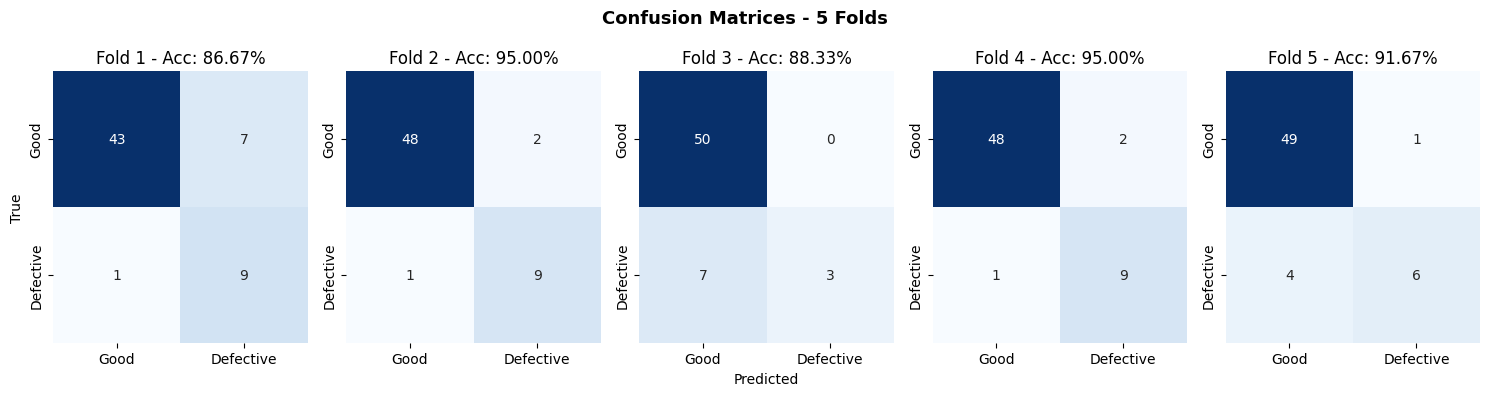

In [ ]:
# Plot one confusion matrix per cross-validation fold.
if len(fold_results['confusion_matrices']) == 0:
    print("Confusion matrix plots are unavailable because the training step did not complete.")
else:
    num_folds_available = len(fold_results['confusion_matrices'])
    fig, axes = plt.subplots(1, num_folds_available, figsize=(max(6, 3 * num_folds_available), 4))
    fig.suptitle(f'Confusion Matrices - {num_folds_available} Folds', fontsize=13, fontweight='bold')

    if num_folds_available == 1:
        axes = [axes]

    for fold_idx in range(num_folds_available):
        ax = axes[fold_idx]
        cm = fold_results['confusion_matrices'][fold_idx]
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                    xticklabels=['Good', 'Defective'], yticklabels=['Good', 'Defective'],
                    cbar=False)
        ax.set_title(f"Fold {fold_idx + 1} - Acc: {fold_results['val_acc'][fold_idx]:.2%}")
        ax.set_ylabel('True' if fold_idx == 0 else '')
        ax.set_xlabel('Predicted' if fold_idx == (num_folds_available // 2) else '')
 
    plt.tight_layout()
    plt.show()

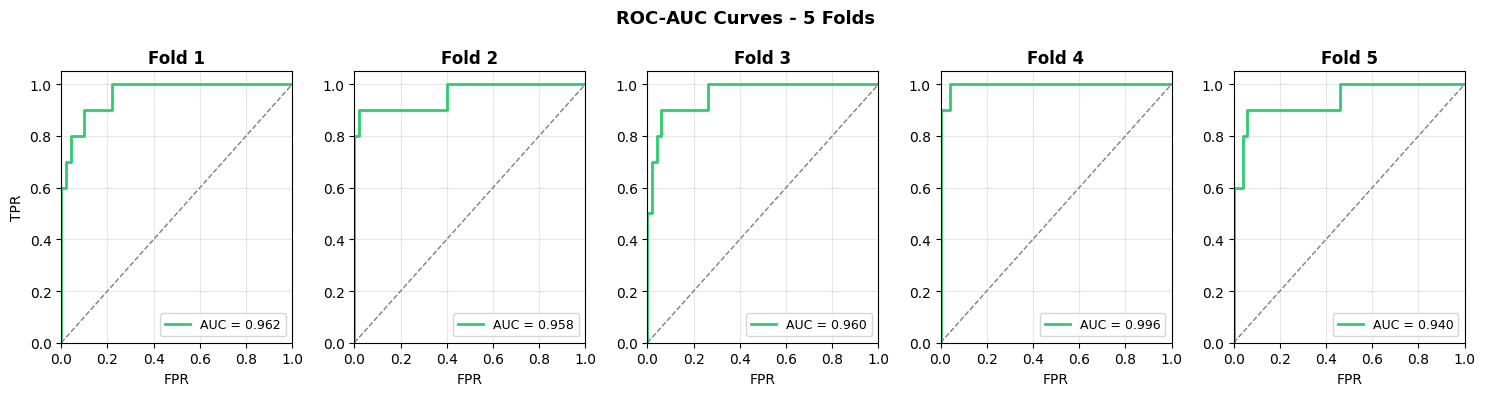

In [ ]:
# Plot ROC curves and AUC values for each validation fold.
if len(fold_results['all_labels']) == 0:
    print("ROC-AUC plots are unavailable because the training step did not complete.")
else:
    num_folds_available = len(fold_results['all_labels'])
    fig, axes = plt.subplots(1, num_folds_available, figsize=(max(6, 3 * num_folds_available), 4))
    fig.suptitle(f'ROC-AUC Curves - {num_folds_available} Folds', fontsize=13, fontweight='bold')

    if num_folds_available == 1:
        axes = [axes]

    for fold_idx in range(num_folds_available):
        ax = axes[fold_idx]

        fpr, tpr, _ = roc_curve(fold_results['all_labels'][fold_idx], 
                                fold_results['all_probs'][fold_idx])
        auc_score = fold_results['val_auc'][fold_idx]

        ax.plot(fpr, tpr, color='#2ecc71', lw=2, label=f'AUC = {auc_score:.3f}')
        ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1.05])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR' if fold_idx == 0 else '')
        ax.set_title(f'Fold {fold_idx + 1}', fontweight='bold')
        ax.legend(loc='lower right', fontsize=9)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
# Print a concise cross-validation performance summary.
if len(fold_results['val_acc']) == 0:
    print("\nCross-validation performance summary")
    print("-" * 45)
    print("Cross-validation metrics are unavailable because the training step did not complete.")
else:
    mean_acc = np.mean(fold_results['val_acc'])
    mean_recall = np.mean(fold_results['val_recall'])
    mean_precision = np.mean(fold_results['val_precision'])
    mean_f1 = np.mean(fold_results['val_f1'])
    mean_auc = np.mean(fold_results['val_auc'])

    std_acc = np.std(fold_results['val_acc'])
    std_recall = np.std(fold_results['val_recall'])
    std_precision = np.std(fold_results['val_precision'])
    std_f1 = np.std(fold_results['val_f1'])
    std_auc = np.std(fold_results['val_auc'])

    print("\nCross-validation performance summary")
    print("-" * 45)
    print(f"Accuracy : {mean_acc:.4f} +/- {std_acc:.4f}")
    print(f"Recall   : {mean_recall:.4f} +/- {std_recall:.4f}")
    print(f"Precision: {mean_precision:.4f} +/- {std_precision:.4f}")
    print(f"F1-score : {mean_f1:.4f} +/- {std_f1:.4f}")
    print(f"ROC-AUC  : {mean_auc:.4f} +/- {std_auc:.4f}")


Cross-validation performance summary
---------------------------------------------
Accuracy : 0.9133 +/- 0.0340
Recall   : 0.7200 +/- 0.2400
Precision: 0.8112 +/- 0.1412
F1-score : 0.7148 +/- 0.1451
ROC-AUC  : 0.9632 +/- 0.0182


---
# 6. RESULTS SUMMARY
---

In [ ]:
# Print final project metrics and run configuration in a compact, order-independent format.
num_good_summary = train_labels.count(0)
num_defective_summary = train_labels.count(1)

print(f"\n\n{'='*70}")
print(f"PROJECT COMPLETION SUMMARY")
print(f"{'='*70}\n")
print(f"Dataset: MVTec Screw (Good vs Defective)")
print(f"Total Training Samples: {len(train_images)} (Good: {num_good_summary}, Defective: {num_defective_summary})")
print(f"Class Imbalance Ratio: {num_good_summary / max(num_defective_summary, 1):.1f}:1")
print(f"Model Architecture: ResNet18 (Pre-trained on ImageNet)")
print(f"Validation Strategy: {CONFIG['NUM_FOLDS']}-Fold Stratified Cross-Validation")
print(f"Loss Function: CrossEntropyLoss + Class Weights")
print(f"Data Augmentation: Rotation + Horizontal/Vertical Flip")
print(f"Max Epochs: {CONFIG['NUM_EPOCHS']} (with early stopping)")

if len(fold_results['val_acc']) == 0:
    print("\nFINAL METRICS:")
    print("   Cross-validation metrics are unavailable because the training step did not complete.")
else:
    print(f"\nFINAL METRICS (Mean +/- Std across {len(fold_results['val_acc'])} folds):")
    print(f"   Accuracy:  {np.mean(fold_results['val_acc']):.4f} +/- {np.std(fold_results['val_acc']):.4f}")
    print(f"   Recall:    {np.mean(fold_results['val_recall']):.4f} +/- {np.std(fold_results['val_recall']):.4f}")
    print(f"   Precision: {np.mean(fold_results['val_precision']):.4f} +/- {np.std(fold_results['val_precision']):.4f}")
    print(f"   F1-Score:  {np.mean(fold_results['val_f1']):.4f} +/- {np.std(fold_results['val_f1']):.4f}")
    print(f"   ROC-AUC:   {np.mean(fold_results['val_auc']):.4f} +/- {np.std(fold_results['val_auc']):.4f}")

print(f"\n{'='*70}")
print(f"Analysis completed successfully!")
print(f"{'='*70}")



PROJECT COMPLETION SUMMARY

Dataset: MVTec Screw (Good vs Defective)
Total Training Samples: 300 (Good: 250, Defective: 50)
Class Imbalance Ratio: 5.0:1
Model Architecture: ResNet18 (Pre-trained on ImageNet)
Validation Strategy: 5-Fold Stratified Cross-Validation
Loss Function: CrossEntropyLoss + Class Weights
Data Augmentation: Rotation + Horizontal/Vertical Flip
Max Epochs: 50 (with early stopping)

FINAL METRICS (Mean +/- Std across 5 folds):
   Accuracy:  0.9133 +/- 0.0340
   Recall:    0.7200 +/- 0.2400
   Precision: 0.8112 +/- 0.1412
   F1-Score:  0.7148 +/- 0.1451
   ROC-AUC:   0.9632 +/- 0.0182

Analysis completed successfully!


In [ ]:
# Report memory footprint of stored best fold checkpoints.
print(f"Stored {len(fold_results['best_model_states'])} best model snapshots in memory")
if fold_results['best_model_states']:
    sample_state = fold_results['best_model_states'][0]
    tensor_mb = sum(v.numel() * v.element_size() for v in sample_state.values()) / (1024 * 1024)
    print(f"Approx snapshot size: {tensor_mb:.2f} MB")

Stored 5 best model snapshots in memory
Approx snapshot size: 42.68 MB


---
# 6. BEST MODEL SELECTION & SAVING
---

In [ ]:
# Select the best-performing fold and save its model weights.
if len(fold_results['best_model_states']) == 0:
    raise RuntimeError("Cross-validation did not produce any model checkpoints.")

best_fold_idx = np.argmax(fold_results['val_acc'])
best_fold_num = best_fold_idx + 1
best_fold_state = fold_results['best_model_states'][best_fold_idx]

print(f"Best Model: Fold {best_fold_num} (Accuracy: {fold_results['val_acc'][best_fold_idx]:.2%})")
print(f"  Recall: {fold_results['val_recall'][best_fold_idx]:.2%} | Precision: {fold_results['val_precision'][best_fold_idx]:.2%} | ROC-AUC: {fold_results['val_auc'][best_fold_idx]:.3f}")

# Load best in-memory state and export the artifact
model = CustomResNet18(num_classes=2, pretrained=False).to(device)
model.load_state_dict(best_fold_state)
model.eval()

artifact_path = "best_model.pth"
torch.save(best_fold_state, artifact_path)

print("Loaded best fold model state from memory")
print(f"Saved best fold artifact to {artifact_path}")

Best Model: Fold 2 (Accuracy: 95.00%)
  Recall: 90.00% | Precision: 81.82% | ROC-AUC: 0.958
Loaded best fold model state from memory
Saved best fold artifact to best_model.pth


---
# 7. TEST SET INFERENCE - Qualitative Results on Unlabeled Test Images
---


5-Fold Training Complete
Running inference on 180 test images...
Test Results: 132 Good (73.3%), 48 Defective (26.7%)
Mean Confidence: 85.05%


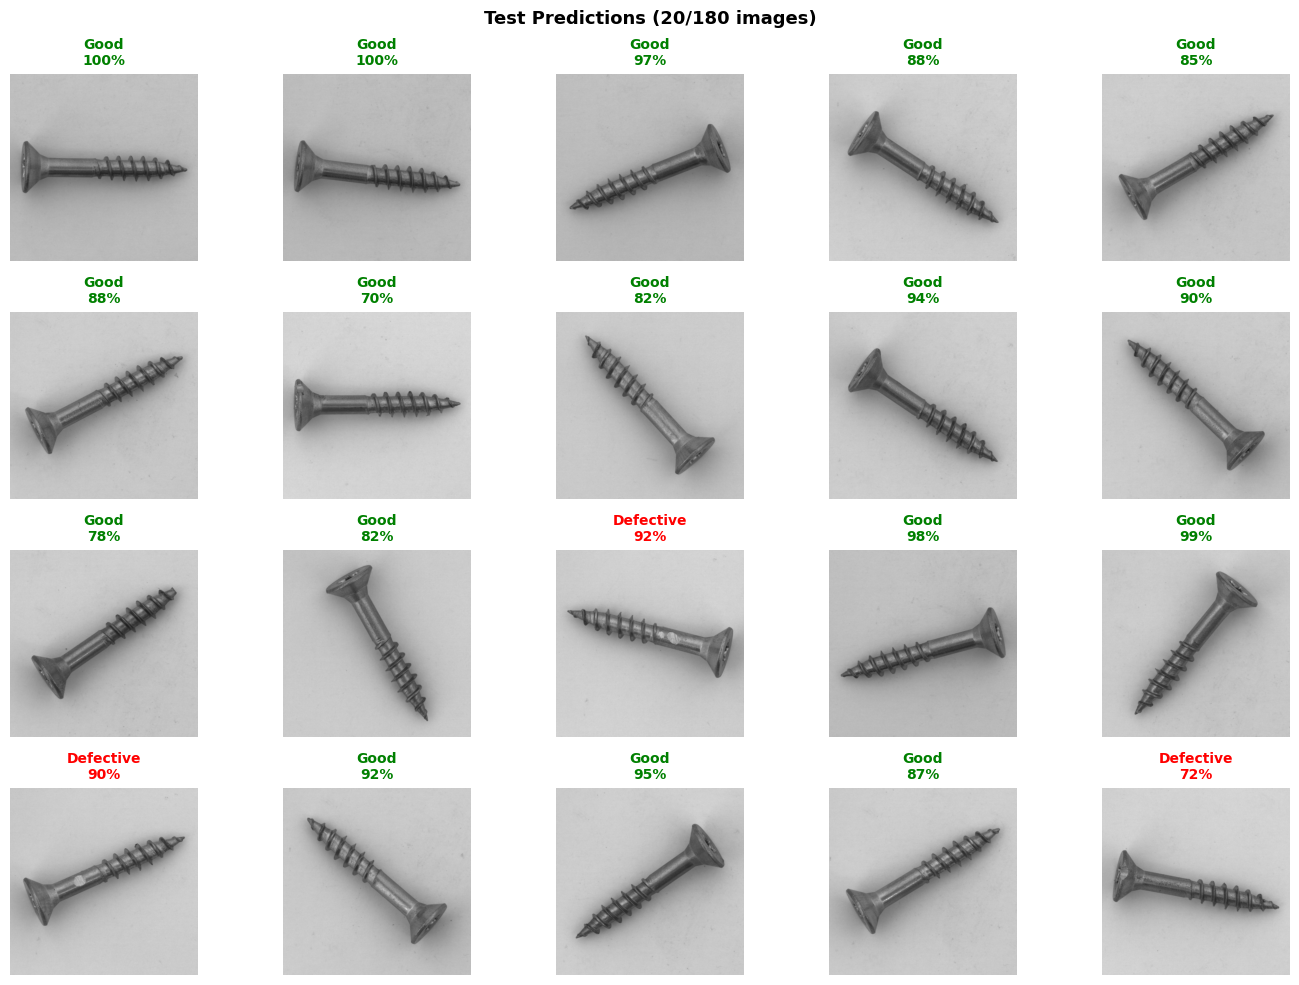

In [ ]:
# Run inference on unlabeled test images and visualize predictions.
print(f"\n5-Fold Training Complete")

# Load test images with extension fallbacks and deduplicate on case-insensitive file systems
test_image_patterns = ['*.png', '*.PNG', '*.jpg', '*.JPG', '*.jpeg', '*.JPEG']
test_candidates = []
for pattern in test_image_patterns:
    test_candidates.extend(sorted(test_dir.glob(pattern)))
test_images_paths = list(dict.fromkeys(test_candidates))

if len(test_images_paths) > 0:
    print(f"Running inference on {len(test_images_paths)} test images...")
    
    test_dataset = ScrewDataset([str(p) for p in test_images_paths], [0]*len(test_images_paths), transform=val_transform)
    test_loader = DataLoader(test_dataset, batch_size=CONFIG['BATCH_SIZE'], shuffle=False)
    
    model.eval()
    test_predictions, test_confidence = [], []
    
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)
            confidence = torch.max(probs, dim=1)[0]
            
            test_predictions.extend(preds.cpu().numpy())
            test_confidence.extend(confidence.cpu().numpy())
    
    num_defective = sum(test_predictions)
    num_good = len(test_predictions) - num_defective
    
    print(f"Test Results: {num_good} Good ({100*num_good/len(test_predictions):.1f}%), {num_defective} Defective ({100*num_defective/len(test_predictions):.1f}%)")
    print(f"Mean Confidence: {np.mean(test_confidence):.2%}")
    
    # Visualize predictions
    num_display = min(20, len(test_images_paths))
    num_cols = 5
    num_rows = (num_display + num_cols - 1) // num_cols
    
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(14, 10))
    fig.suptitle(f'Test Predictions ({num_display}/{len(test_images_paths)} images)', fontsize=13, fontweight='bold')
    axes = axes.flatten()
    
    for idx in range(num_display):
        img = Image.open(test_images_paths[idx]).convert('RGB')
        ax = axes[idx]
        ax.imshow(img)
        
        pred_label = "Defective" if test_predictions[idx] == 1 else "Good"
        color = 'red' if test_predictions[idx] == 1 else 'green'
        conf = test_confidence[idx]
        
        ax.set_title(f'{pred_label}\n{conf:.0%}', color=color, fontweight='bold', fontsize=10)
        ax.axis('off')
    
    for idx in range(num_display, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

In [ ]:
# Report only test discovery issues when no supported files are found.
if len(test_images_paths) == 0:
    discovered = [p.name for p in sorted(test_dir.glob('*'))]
    print(f"No supported test images found in {test_dir}")
    print(f"Expected extensions: {', '.join(test_image_patterns)}")
    print(f"Discovered entries: {discovered[:10]}")